"""
# **Gradient Descent and Convex Functions - Coding Assignment** **[30 points]**

## **Objective:**
In this assignment, students will explore **Gradient Descent (GD)** and **Projected Gradient Descent (PGD)** on a convex function. They will:
- Understand the **concept of convex functions**.
- Implement **Gradient Descent (GD)** for optimization.
- Visualize the **convergence rate** of GD over iterations.
- Implement **Projected Gradient Descent (PGD)** for constrained optimization.
- Compare the performance of GD vs. PGD.

---

Criteria	Points
1. Compute the gradient	- 10
2. Generate x values and plot the function using matplotlib - 	10
3. Implement Gradient Descent algorithm	10
4. Run GD with different learning rates and plot convergence - 10
5. Implement projection function - 5
6. Implement Projected Gradient Descent (PGD) - 5
7. Run PGD and plot convergence for different learning rates - 5
8. Final Task: Answer markdown questions (1 point each) - 5

## **1. Load Libraries and Define Convex Function**
"""

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### **Task 1: Define a Simple Convex Function**
Consider two functions:

\[
f(x) = x^2 + 2x + 1
\]

and

\[
f(x)=log(1+exp(−yw^Tx)), w = [1 -0.5 0.8 3]
\]

Compute its gradient and Hessian.

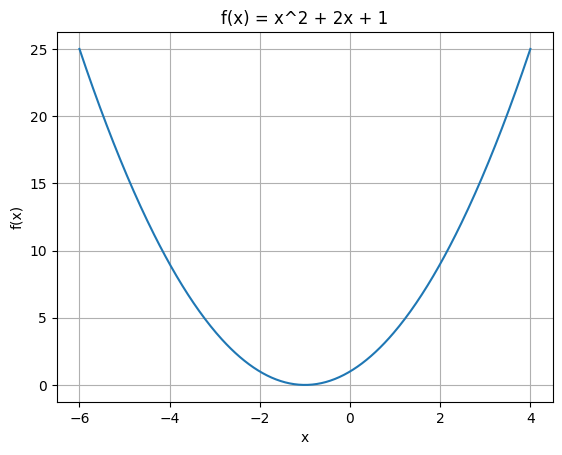

In [2]:
# Define the convex function
def f(x):
    """
    TODO: Implement the convex function f(x) = x^2 + 2x + 1
    Return the function value at x
    """
    return x**2 + 2*x + 1

# Compute the gradient : (10 points)
def grad_f(x):
    """
    TODO: Implement the gradient of f(x), which is the derivative of the function
    Hint: Derivative of x^2 + 2x + 1 is 2x + 2
    """
    return 2*x + 2

# TODO: Generate x values and plot the function using matplotlib (10 points)

x_vals = np.linspace(-6, 4, 400)
y_vals = f(x_vals)

plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = x^2 + 2x + 1")
plt.grid(True)
plt.show()

"""
## **2. Implement Gradient Descent (GD)**
### Task 2: Implement **Gradient Descent Algorithm** for minimizing `f(x)`.
"""

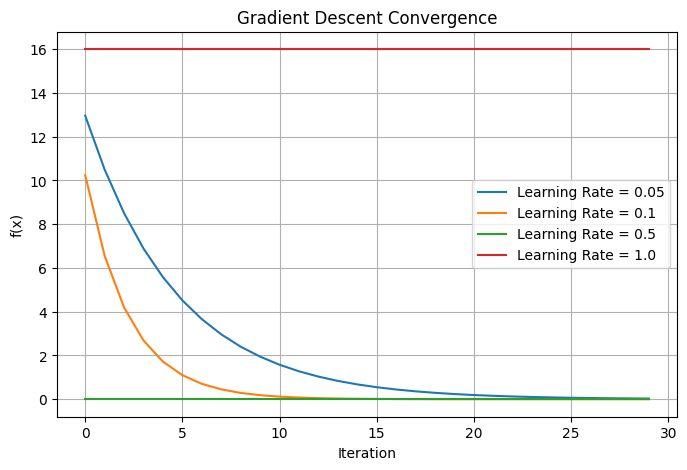

In [4]:
def gradient_descent(learning_rate, steps, x_init):
    """
    TODO: Implement Gradient Descent algorithm (10 points)
    - Initialize x with x_init
    - For each step:
        - Update x using the gradient and learning rate
        - Store the value of f(x) in a list
    Return the list of function values over iterations
    """
    x = x_init
    history = []

    for i in range(steps):
        x = x - learning_rate * grad_f(x)
        history.append(f(x))

    return history

# TODO: Run GD with different learning rates and plot convergence (10 points)

steps = 30
x_init = 3
learning_rates = [0.05, 0.1, 0.5, 1.0]

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    history = gradient_descent(lr, steps, x_init)
    plt.plot(history, label=f"Learning Rate = {lr}")

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

"""
## **3. Implement Projected Gradient Descent (PGD)**
### Task 3: Implement **Projected Gradient Descent** with constraint \(||x|| \leq 5\).
"""

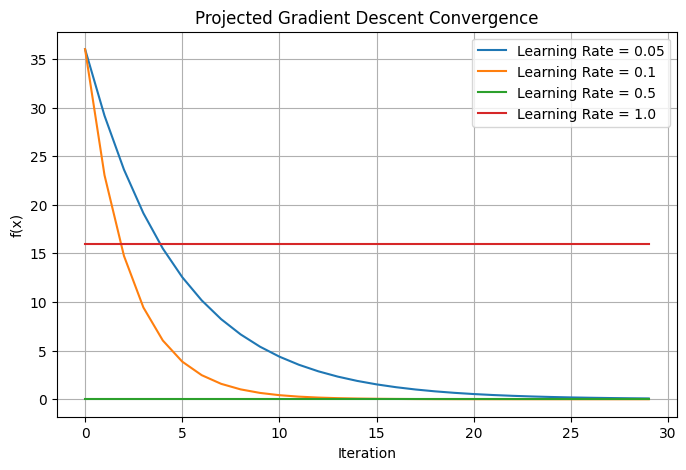

In [5]:
# Projection function
def project(x, r=3):
    """
    TODO: Implement projection function (5 points)
    Hint: if abs(x) > r, return clipped value to keep x within [-r, r]
    """
    return np.clip(x, -r, r)

# Projected Gradient Descent Implementation
def projected_gradient_descent(learning_rate, steps, x_init, r=3):
    """
    TODO: Implement Projected Gradient Descent (5 points)
    - Initialize x
    - For each step:
        - Apply gradient descent update
        - Project x back into the constraint region using the project function
        - Store f(x) in history
    Return the history list
    """
    x = x_init
    history = []

    for i in range(steps):
        x = x - learning_rate * grad_f(x)
        x = project(x, r)
        history.append(f(x))

    return history

# TODO: Run PGD and plot convergence for different learning rates (5 points)

steps = 30
x_init = 8
learning_rates = [0.05, 0.1, 0.5, 1.0]

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    history = projected_gradient_descent(lr, steps, x_init, r=5)
    plt.plot(history, label=f"Learning Rate = {lr}")

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("Projected Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

"""
### **Final Task: Answer the following questions in markdown cells. (1 point each)**
1. What is the effect of different learning rates on GD convergence?
2. Why does PGD enforce constraints on optimization?
3. What happens if we don’t project the values in PGD?
4. Compare GD vs. PGD: In what scenarios would PGD be preferred?
5. How can you modify PGD to work for multi-dimensional convex functions?

---
### **Submission Instructions:**
- Complete all the tasks in this notebook.
- Answer the conceptual questions in markdown cells.
- Submit the completed notebook.
"""


1. The learning rate controls how large each update step is in GD. Small learning rates mean that convergence is very slow. Moderate learning rates mean that convergence is fast and stable. Large learning rates can lead to the model overshooting the minimum or in some cases even diverging.

2. PGD is used when the solution is required to stay inside a specified set. The constraints that PGD enforces on optimization ensure that the GD steps stay inside the allowed region.

3. If values are not projected in PGD then you are just doing regular GD. This means that it is possible for the iterations to leave the region specified in PGD which is not a desirable outcome.

4. GD is preferred when there are no prior constraints on optimization and any point in the domain is allowed. PGD is preferable when there are constraints on the variable and it must stay in a previously specified set. In most machine learning regularization cases, PGD is preferred because it is common to have prior constraints on a variable.

5. For multi-dimensional convex functions, the PGD algorithm remains largely the same. The only difference is that instead of using a single scalar variable x, you would now use a vector of multiple x-variables.